<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/03_TrustMark_desde_Manifest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — TrustMark desde manifest


Aplica **TrustMark** a las imágenes faciales reales definidas en el manifest del conjunto LFW.  
El notebook genera una versión marcada de cada imagen, verifica la recuperación del payload y calcula métricas de calidad visual para establecer la referencia del experimento.

**TrustMark** es la implementación abierta de Adobe para watermarking robusto de imágenes de resolución arbitraria.

Repositorio oficial: https://github.com/adobe/trustmark


## Configuración experimental

Se utiliza el modelo **Q** de TrustMark con codificación **BCH_5** y un payload binario reproducible. Las imágenes marcadas se guardan en formato PNG para evitar introducir compresión adicional durante esta etapa.

La salida incluye:

- imágenes con watermark;
- manifest de las imágenes generadas;
- métricas PSNR y SSIM;
- verificación de detección y recuperación del payload;
- configuración utilizada en la ejecución.


In [ ]:
# ============================================================
# CELDA 1
# Instalación de TrustMark
# ============================================================

import sys
import subprocess

print("Python:", sys.version)
print()

# Dependencias pequeñas requeridas por TrustMark.
# Conservamos NumPy/PyTorch/Torchvision provistos por Colab.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "omegaconf>=2.1",
    "lightning>=2.0",
    "six>=1.9",
    "einops>=0.4.0",
])

# Instalar TrustMark sin permitir que pip sustituya NumPy
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--no-deps",
    "trustmark==0.9.1",
])

print()
print("✓ TrustMark instalado.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


✓ TrustMark instalado.


In [ ]:
# ============================================================
# Google Drive y rutas del proyecto
# ============================================================
from pathlib import Path

try:
    from google.colab import drive

    drive.mount("/content/drive")

    ROOT = Path(
        "/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026"
    )

except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"


INPUT_IMAGE_DIR = ROOT / "datasets/real/lfw/smoke_10/images"
INPUT_MANIFEST = (
    ROOT / "datasets/real/lfw/smoke_10/manifests/metadata.csv"
)

OUTPUT_DIR = ROOT / "results/trustmark/smoke_10"
OUTPUT_IMAGE_DIR = OUTPUT_DIR / "images"
OUTPUT_MANIFEST = OUTPUT_DIR / "manifest.csv"
RESULTS_FILE = OUTPUT_DIR / "metrics.csv"
CONFIG_FILE = OUTPUT_DIR / "config.json"

OUTPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("============================================================")
print(" RUTAS DEL EXPERIMENTO")
print("============================================================")
print(f"ROOT:              {ROOT}")
print(f"Imágenes entrada:  {INPUT_IMAGE_DIR}")
print(f"Manifest entrada:  {INPUT_MANIFEST}")
print(f"Salida TrustMark:   {OUTPUT_DIR}")


Mounted at /content/drive
 RUTAS DEL EXPERIMENTO
ROOT:              /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026
Imágenes entrada:  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/images
Manifest entrada:  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/datasets/real/lfw/smoke_10/manifests/metadata.csv
Salida TrustMark:   /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10


In [ ]:
# ============================================================
# Leer y validar el manifest de entrada
# ============================================================
import pandas as pd

assert INPUT_MANIFEST.exists(), (
    "No se encontró el manifest de entrada:\n"
    f"{INPUT_MANIFEST}\n\n"
    "Ejecuta primero el notebook 01_LFW_FiftyOne_10."
)

manifest = pd.read_csv(INPUT_MANIFEST)

required_columns = {
    "index",
    "filename",
    "class_label",
    "source_dataset",
    "source_id",
    "split",
    "seed",
}

missing = required_columns - set(manifest.columns)

assert not missing, (
    f"Faltan columnas requeridas en el manifest: {sorted(missing)}"
)

assert len(manifest) == 10, (
    f"Se esperaban 10 imágenes y el manifest contiene {len(manifest)}."
)

missing_files = []

for filename in manifest["filename"]:
    image_path = INPUT_IMAGE_DIR / filename

    if not image_path.exists():
        missing_files.append(str(image_path))

assert not missing_files, (
    "No se encontraron algunas imágenes indicadas en el manifest:\n"
    + "\n".join(missing_files)
)

print("============================================================")
print(" MANIFEST VALIDADO")
print("============================================================")
print(f"Registros: {len(manifest)}")
print()
display(manifest)


 MANIFEST VALIDADO
Registros: 10



,index,filename,class_label,source_dataset,person,source_id,width,height,mode,split,seed,sha256
0,1,real_001.jpg,real,LFW,Elizabeth_Smart,Elizabeth_Smart_0002,250,250,RGB,test,2026,c41526beca61431d9bfcd41cf0e35e51c9c287fce79c11...
1,2,real_002.jpg,real,LFW,Thaksin_Shinawatra,Thaksin_Shinawatra_0002,250,250,RGB,test,2026,f9d2a7994e4a9743dad75c0e2f54d600186b886b144b3d...
2,3,real_003.jpg,real,LFW,Jenna_Elfman,Jenna_Elfman_0001,250,250,RGB,test,2026,9c2bf4ae1bc881cf58e7b33f4736db8a1c1618b5aa644e...
3,4,real_004.jpg,real,LFW,Tommy_Haas,Tommy_Haas_0002,250,250,RGB,test,2026,35e511129b8ab0fee5ec40ba30cfee20c7090be5b935e8...
4,5,real_005.jpg,real,LFW,Shannon_OBrien,Shannon_OBrien_0002,250,250,RGB,test,2026,0318d51cca8cb7a68d65a05c5c31806e4ac685d501cbd5...
5,6,real_006.jpg,real,LFW,Ian_Thorpe,Ian_Thorpe_0004,250,250,RGB,test,2026,ed361f533b3c98853e1a5097c2f7fdb781ca6f6e402fc3...
6,7,real_007.jpg,real,LFW,Yoriko_Kawaguchi,Yoriko_Kawaguchi_0003,250,250,RGB,test,2026,7a6750dea2f0fa5ccdc067cdf766bf3bcdaa38b08e01a2...
7,8,real_008.jpg,real,LFW,Christopher_Reeve,Christopher_Reeve_0004,250,250,RGB,test,2026,f6bae23ebed089267a417aa2d742efe6b8974267487212...
8,9,real_009.jpg,real,LFW,Gene_Robinson,Gene_Robinson_0004,250,250,RGB,test,2026,58fee64f7fbd8a4c7e77e1b7c078e66b517150caffdc69...
9,10,real_010.jpg,real,LFW,Robert_Redford,Robert_Redford_0006,250,250,RGB,test,2026,cae2fa053fcb3e7dc3b2e4f8ca19dfe199babd8e2c12c8...


In [ ]:
# ============================================================
# Configuración de TrustMark
# ============================================================
from trustmark import TrustMark
import random
import hashlib
import json

SEED = 2026
MODEL_TYPE = "Q"
ENCODING_NAME = "BCH_5"
WM_STRENGTH = 1.0

tm = TrustMark(
    verbose=True,
    model_type=MODEL_TYPE,
    encoding_type=TrustMark.Encoding.BCH_5,
    loadBBoxDetector=False,
)

PAYLOAD_BITS = tm.schemaCapacity()

rng = random.Random(SEED)

payload = "".join(
    rng.choice("01")
    for _ in range(PAYLOAD_BITS)
)

payload_sha256 = hashlib.sha256(
    payload.encode("utf-8")
).hexdigest()

config = {
    "method": "TrustMark",
    "model_type": MODEL_TYPE,
    "encoding": ENCODING_NAME,
    "wm_strength": WM_STRENGTH,
    "payload_mode": "binary",
    "payload_seed": SEED,
    "payload_bits": PAYLOAD_BITS,
    "payload": payload,
    "payload_sha256": payload_sha256,
    "input_manifest": str(INPUT_MANIFEST),
}

with open(CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("============================================================")
print(" CONFIGURACIÓN TRUSTMARK")
print("============================================================")
print(f"Modelo:          {MODEL_TYPE}")
print(f"Codificación:    {ENCODING_NAME}")
print(f"WM_STRENGTH:     {WM_STRENGTH}")
print(f"Payload:         binario")
print(f"Bits de payload: {PAYLOAD_BITS}")
print(f"Semilla:         {SEED}")
print()
print(f"Configuración guardada en:\n{CONFIG_FILE}")


Initializing TrustMark watermarking with ECC using [cpu]
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/trustmark_Q.yaml
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/decoder_Q.ckpt
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/encoder_Q.ckpt
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/trustmark_rm_Q.yaml
Fetching model file (once only): /usr/local/lib/python3.13/dist-packages/trustmark/models/trustmark_rm_Q.ckpt
 CONFIGURACIÓN TRUSTMARK
Modelo:          Q
Codificación:    BCH_5
WM_STRENGTH:     1.0
Payload:         binario
Bits de payload: 61
Semilla:         2026

Configuración guardada en:
/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/config.json


In [ ]:
# ============================================================
# Funciones auxiliares
# ============================================================

import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def bit_accuracy(expected, recovered):
    """
    Calcula la proporción de bits recuperados correctamente.
    """
    if recovered is None:
        return 0.0

    recovered = str(recovered)

    if len(recovered) == 0:
        return 0.0

    n = min(len(expected), len(recovered))

    correct = sum(
        a == b
        for a, b in zip(expected[:n], recovered[:n])
    )

    return correct / len(expected)


def compute_metrics(original, watermarked):
    """
    Calcula PSNR y SSIM entre dos imágenes RGB del mismo tamaño.
    """
    A = np.asarray(original, dtype=np.uint8)
    B = np.asarray(watermarked, dtype=np.uint8)

    assert A.shape == B.shape, (
        f"Las imágenes tienen tamaños diferentes: {A.shape} vs {B.shape}"
    )

    psnr = peak_signal_noise_ratio(
        A,
        B,
        data_range=255,
    )

    ssim = structural_similarity(
        A,
        B,
        channel_axis=2,
        data_range=255,
    )

    return float(psnr), float(ssim)


In [ ]:
# ============================================================
# Insertar y recuperar TrustMark
# ============================================================
from PIL import Image

rows = []
output_manifest_rows = []

for _, row in manifest.iterrows():

    input_path = INPUT_IMAGE_DIR / row["filename"]

    with Image.open(input_path) as source:
        original = source.convert("RGB")

    watermarked = tm.encode(
        original,
        payload,
        MODE="binary",
        WM_STRENGTH=WM_STRENGTH,
    ).convert("RGB")

    assert watermarked.size == original.size, (
        f"El tamaño cambió para {row['filename']}: "
        f"{original.size} -> {watermarked.size}"
    )

    recovered, present, schema = tm.decode(watermarked)

    output_filename = (
        f"{Path(row['filename']).stem}_trustmark.png"
    )

    output_path = OUTPUT_IMAGE_DIR / output_filename

    watermarked.save(
        output_path,
        format="PNG",
    )

    psnr, ssim = compute_metrics(
        original,
        watermarked,
    )

    accuracy = bit_accuracy(
        payload,
        recovered if present else "",
    )

    rows.append({
        "index": int(row["index"]),
        "source_filename": row["filename"],
        "watermarked_filename": output_filename,
        "class_label": row["class_label"],
        "source_dataset": row["source_dataset"],
        "source_id": row["source_id"],
        "trustmark_model": MODEL_TYPE,
        "encoding": ENCODING_NAME,
        "wm_strength": WM_STRENGTH,
        "watermark_present": bool(present),
        "schema": schema,
        "bit_accuracy": accuracy,
        "psnr": psnr,
        "ssim": ssim,
    })

    output_manifest_rows.append({
        "index": int(row["index"]),
        "source_filename": row["filename"],
        "watermarked_filename": output_filename,
        "source_path": str(input_path),
        "watermarked_path": str(output_path),
        "class_label": row["class_label"],
        "source_dataset": row["source_dataset"],
        "source_id": row["source_id"],
        "method": "TrustMark",
        "model_type": MODEL_TYPE,
        "encoding": ENCODING_NAME,
        "wm_strength": WM_STRENGTH,
        "payload_seed": SEED,
        "payload_sha256": payload_sha256,
    })

    print(
        f"✓ {row['filename']} -> {output_filename} | "
        f"detectado={bool(present)} | "
        f"bit_acc={accuracy:.4f} | "
        f"PSNR={psnr:.2f} dB | "
        f"SSIM={ssim:.4f}"
    )

print()
print("✓ Procesamiento completado.")

✓ real_001.jpg -> real_001_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=43.35 dB | SSIM=0.9876
✓ real_002.jpg -> real_002_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=41.46 dB | SSIM=0.9822
✓ real_003.jpg -> real_003_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=41.91 dB | SSIM=0.9817
✓ real_004.jpg -> real_004_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=42.94 dB | SSIM=0.9856
✓ real_005.jpg -> real_005_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=42.23 dB | SSIM=0.9857
✓ real_006.jpg -> real_006_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=42.14 dB | SSIM=0.9846
✓ real_007.jpg -> real_007_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=43.07 dB | SSIM=0.9881
✓ real_008.jpg -> real_008_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=43.46 dB | SSIM=0.9883
✓ real_009.jpg -> real_009_trustmark.png | detectado=True | bit_acc=0.0000 | PSNR=44.70 dB | SSIM=0.9879
✓ real_010.jpg -> real_010_trustmark.png | detectado=Tr

In [ ]:
# ============================================================
# Guardar resultados
# ============================================================

results_df = pd.DataFrame(rows)
output_manifest_df = pd.DataFrame(output_manifest_rows)

results_df.to_csv(
    RESULTS_FILE,
    index=False,
)

output_manifest_df.to_csv(
    OUTPUT_MANIFEST,
    index=False,
)

print("============================================================")
print(" RESULTADOS")
print("============================================================")
print()
display(results_df)

print()
print("Promedios:")
display(
    results_df[
        ["watermark_present", "bit_accuracy", "psnr", "ssim"]
    ].mean(numeric_only=True).to_frame("mean")
)

print()
print(f"Métricas:  {RESULTS_FILE}")
print(f"Manifest:  {OUTPUT_MANIFEST}")


 RESULTADOS



,index,source_filename,watermarked_filename,class_label,source_dataset,source_id,trustmark_model,encoding,wm_strength,watermark_present,schema,bit_accuracy,psnr,ssim
0,1,real_001.jpg,real_001_trustmark.png,real,LFW,Elizabeth_Smart_0002,Q,BCH_5,1.0,True,1,0.0,43.345716,0.987577
1,2,real_002.jpg,real_002_trustmark.png,real,LFW,Thaksin_Shinawatra_0002,Q,BCH_5,1.0,True,1,0.0,41.460605,0.982239
2,3,real_003.jpg,real_003_trustmark.png,real,LFW,Jenna_Elfman_0001,Q,BCH_5,1.0,True,1,0.0,41.914389,0.981714
3,4,real_004.jpg,real_004_trustmark.png,real,LFW,Tommy_Haas_0002,Q,BCH_5,1.0,True,1,0.0,42.941125,0.985554
4,5,real_005.jpg,real_005_trustmark.png,real,LFW,Shannon_OBrien_0002,Q,BCH_5,1.0,True,1,0.0,42.234399,0.985734
5,6,real_006.jpg,real_006_trustmark.png,real,LFW,Ian_Thorpe_0004,Q,BCH_5,1.0,True,1,0.0,42.136800,0.984643
6,7,real_007.jpg,real_007_trustmark.png,real,LFW,Yoriko_Kawaguchi_0003,Q,BCH_5,1.0,True,1,0.0,43.069312,0.988108
7,8,real_008.jpg,real_008_trustmark.png,real,LFW,Christopher_Reeve_0004,Q,BCH_5,1.0,True,1,0.0,43.463804,0.988291
8,9,real_009.jpg,real_009_trustmark.png,real,LFW,Gene_Robinson_0004,Q,BCH_5,1.0,True,1,0.0,44.702683,0.987856
9,10,real_010.jpg,real_010_trustmark.png,real,LFW,Robert_Redford_0006,Q,BCH_5,1.0,True,1,0.0,41.954242,0.982615



Promedios:


,mean
watermark_present,1.000000
bit_accuracy,0.000000
psnr,42.722308
ssim,0.985433



Métricas:  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/metrics.csv
Manifest:  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/manifest.csv


In [ ]:
# ============================================================
# Verificaciones del experimento
# ============================================================

generated_files = sorted(
    OUTPUT_IMAGE_DIR.glob("*_trustmark.png")
)

assert len(generated_files) == len(manifest), (
    f"Se esperaban {len(manifest)} imágenes marcadas "
    f"y se encontraron {len(generated_files)}."
)

for path in generated_files:
    with Image.open(path) as img:
        img.verify()

assert len(results_df) == len(manifest)
assert len(output_manifest_df) == len(manifest)

print("============================================================")
print(" VERIFICACIÓN")
print("============================================================")
print(f"Imágenes originales:   {len(manifest)}")
print(f"Imágenes con TrustMark:{len(generated_files)}")
print(
    "Watermark detectado:  "
    f"{int(results_df['watermark_present'].sum())}/"
    f"{len(results_df)}"
)
print(
    "Bit accuracy media:   "
    f"{results_df['bit_accuracy'].mean():.4f}"
)
print(
    "PSNR medio:           "
    f"{results_df['psnr'].mean():.2f} dB"
)
print(
    "SSIM medio:           "
    f"{results_df['ssim'].mean():.4f}"
)
print()
print("✓ Archivos y resultados verificados.")


 VERIFICACIÓN
Imágenes originales:   10
Imágenes con TrustMark:10
Watermark detectado:  10/10
Bit accuracy media:   0.0000
PSNR medio:           42.72 dB
SSIM medio:           0.9854

✓ Archivos y resultados verificados.


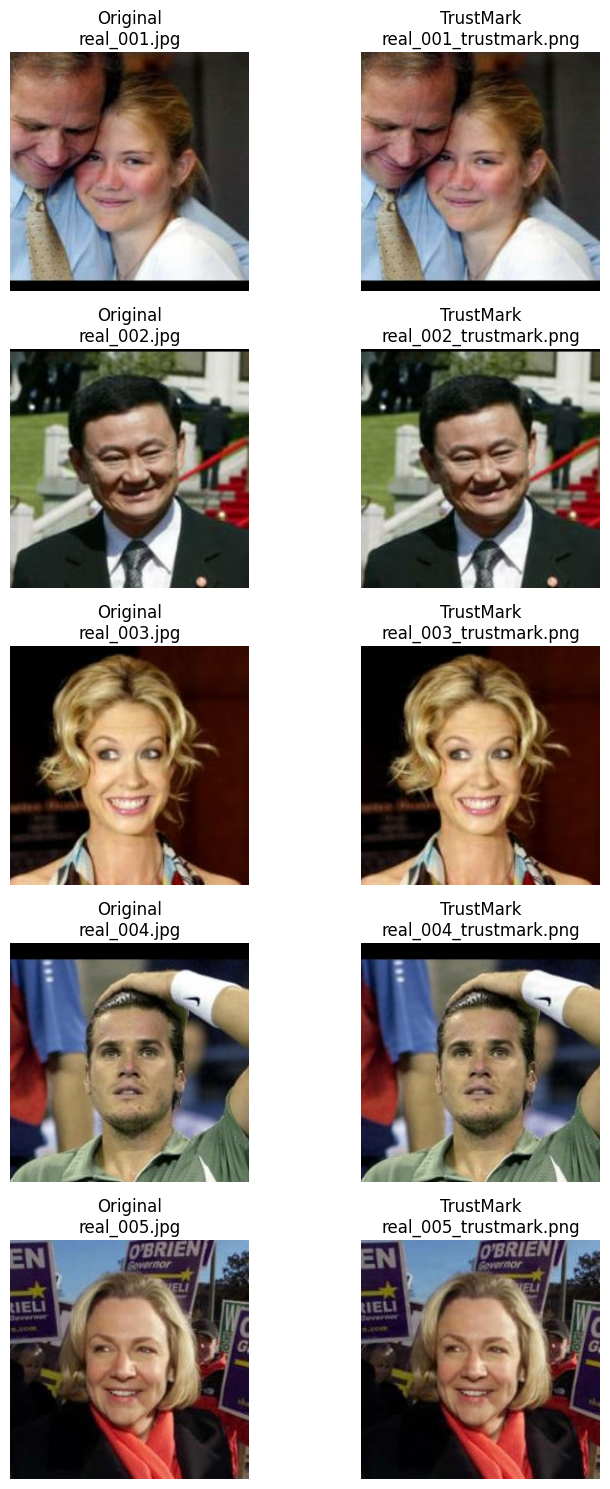

In [ ]:
# ============================================================
# Comparación visual
# ============================================================

import matplotlib.pyplot as plt

n_show = min(5, len(manifest))

fig, axes = plt.subplots(
    n_show,
    2,
    figsize=(8, 3 * n_show),
)

if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):

    source_filename = manifest.iloc[i]["filename"]

    watermarked_filename = (
        f"{Path(source_filename).stem}_trustmark.png"
    )

    with Image.open(INPUT_IMAGE_DIR / source_filename) as img:
        original = img.convert("RGB").copy()

    with Image.open(
        OUTPUT_IMAGE_DIR / watermarked_filename
    ) as img:
        marked = img.convert("RGB").copy()

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original\n{source_filename}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(marked)
    axes[i, 1].set_title(
        f"TrustMark\n{watermarked_filename}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Resumen
# ============================================================

print("============================================================")
print(" 03_TrustMark_desde_Manifest COMPLETADO")
print("============================================================")
print()
print(f"Fuente:             LFW")
print(f"Imágenes:           {len(manifest)}")
print(f"Modelo TrustMark:   {MODEL_TYPE}")
print(f"Codificación:       {ENCODING_NAME}")
print(f"Payload:            {PAYLOAD_BITS} bits")
print(f"WM_STRENGTH:        {WM_STRENGTH}")
print()
print("Imágenes marcadas:")
print(f"  {OUTPUT_IMAGE_DIR}")
print()
print("Manifest:")
print(f"  {OUTPUT_MANIFEST}")
print()
print("Métricas:")
print(f"  {RESULTS_FILE}")
print()
print("Configuración:")
print(f"  {CONFIG_FILE}")
print()
print("✓ TrustMark aplicado a la muestra facial real.")


 03_TrustMark_desde_Manifest COMPLETADO

Fuente:             LFW
Imágenes:           10
Modelo TrustMark:   Q
Codificación:       BCH_5
Payload:            61 bits
WM_STRENGTH:        1.0

Imágenes marcadas:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/images

Manifest:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/manifest.csv

Métricas:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/metrics.csv

Configuración:
  /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/trustmark/smoke_10/config.json

✓ TrustMark aplicado a la muestra facial real.
